# Задача 3. Реализация обхода в ширину из нескольких стартовых вершин (Multiple-Source BFS)

In [ ]:
!pip install python-graphblas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 25.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import graphblas as gb
from graphblas import Matrix, Vector, Scalar
from graphblas import dtypes
from graphblas import unary, binary, monoid, semiring

# Задача 1

Везде считаем, что вершины графа занумерованы подряд с нуля.

 * Используя python-graphblas реализовать функцию обхода ориентированного графа (MSBFS-Levels) в ширину из нескольких заданных стартовых вершин.
 Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.  

 * Функция возвращает массив пар: стартовая вершина, и массив (levels), где для каждой вершины указано, на каком уровне она достижима из этой стартовой. Стартовая вершина достижима на нулевом уровне, если вершина не достижима, то значение соответствующей ячейки сделайте равной -1.

In [ ]:
def MSBFS_Levels(M, s):
  n = M.nrows #определеям кол-во вершин
  result_1 = Matrix(dtypes.INT32, len(s), n) #создаем матрицу для хранения результатов
  f_1 = Matrix(bool, len(s), n) #создаем фронт вершин
  for i in range(len(s)):
    f_1[i, s[i]] << True #присваиваем начальным вершинам тру
  level = 0
  for level in range(n-1):
    result_1(mask=f_1.V) << level #Записываем результат во фронт
    level += 1
    f_1_before = f_1.dup() #Создаем копию фронта для сравнения
    #перезаписываем результат, используем комплименатрую маску вектора результата (берем струткуру .S)
    f_1(~result_1.S, replace=True) << f_1.mxm(M, semiring.lor_land) # Матричное умножение в полукольце булевом для вычисления следующего фронта вершин
    if f_1.isequal(f_1_before):  # Если фронт не изменился, то прерываем цикл
      break
  pairs = []

  for i in range(result_1.shape[0]):
      result_app = result_1[i, :]
      pairs.append([s[i], result_app.to_dense(fill_value=-1).tolist()])
  return pairs

## пример 1

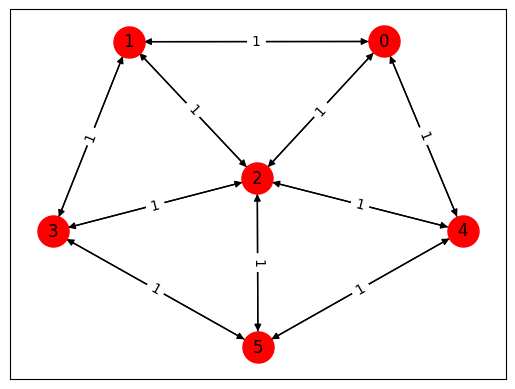

In [ ]:
adjacency_matrix = np.array([
    [0, 1, 1, 0, 1, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 1, 1, 1],
    [0, 1, 1, 0, 0, 1],
    [1, 0, 1, 0, 0, 1],
    [0, 0, 1, 1, 1, 0]
])
A = Matrix.from_dense(adjacency_matrix, dtype=dtypes.INT64)
gb.viz.draw(A.dup(mask=A.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [1,2,5] #стартовые вершины
MSBFS_Levels(A,s)

[[1, [1, 0, 1, 1, 2, 2]], [2, [1, 1, 0, 1, 1, 1]], [5, [2, 2, 1, 1, 1, 0]]]

## пример 2

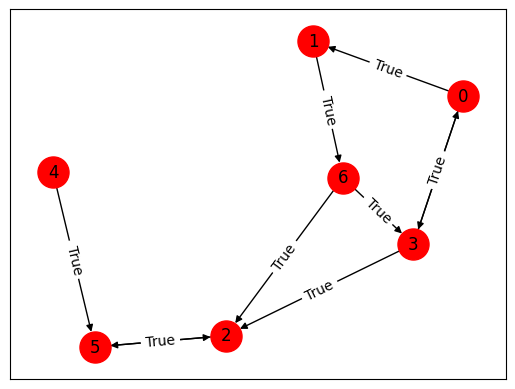

In [ ]:
# Недостижимая вершина 4
edges = [
    [3, 0, 3, 5, 6, 0, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 5, 5, 6],
]
B = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
gb.viz.draw(B.dup(mask=B.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [0,4,5]
MSBFS_Levels(B,s)

[[0, [0, 1, 2, 1, -1, 3, 2]],
 [4, [-1, -1, 2, -1, 0, 1, -1]],
 [5, [-1, -1, 1, -1, -1, 0, -1]]]

## пример 3

In [ ]:
# пример с практики
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]
C = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])

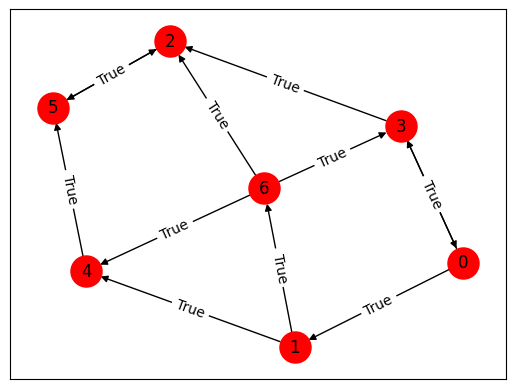

In [ ]:
gb.viz.draw(C.dup(mask=C.dup(dtype=dtypes.BOOL)))

Результаты с практики

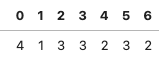

In [ ]:
s=[1]
MSBFS_Levels(C, s)

[[1, [3, 0, 2, 2, 1, 2, 1]]]

# Задача 2

Используя python-graphblas реализовать функцию обхода ориентированного графа (MSBFS-Parents) в ширину из нескольких заданных стартовых вершин.  

 * Функция принимает представление графа, удобное для неё (загрузка, конвертация реализованы отдельно) и массив номеров стартовых вершин.  

 * Функция возвращает массив пар: стартовая вершина, и массив (parents), где для каждой вершины графа указано, из какой вершины мы пришли в эту по кратчайшему пути из стартовой вершины. При этом для самой стартовой вершины такое значение взять равное -1, а для недостижимых вершин взять равное -2. При наличии нескольких возможных значений в массивах parents брать наименьшее.

In [ ]:
def MSBFS_Parents(A, s):
    N = A.nrows  #определеям кол-во вершин
    index_ramp = Matrix(dtypes.UINT64, len(s), N)
    parents = Matrix(dtypes.UINT64, len(s), N)
    row_indices = []
    col_indices = []
    values = []
    for i in range(len(s)):
        for j in range(N):
            row_indices.append(i)
            col_indices.append(j)
            values.append(j)
    index_ramp.build(row_indices, col_indices, values)
    for i in range(len(s)):
        parents[i, s[i]] << N + 1  #Уставновка значения стартовых вершин, чтобы потом поменяться на -1
    wavefront = Matrix(dtypes.UINT64, len(s), N)
    for i in range(len(s)):
        wavefront[i, s[i]] << 0

    while wavefront.nvals > 0:  # Проверка на ненулевые значения
        wavefront << index_ramp.ewise_mult(wavefront, binary.first)
        wavefront(~parents.S, replace=True) << wavefront.mxm(A, semiring.min_first)
        parents(binary.plus) << wavefront

    pairs = []
    for i in range(parents.shape[0]):
        parents_app = parents[i, :]
        pairs.append([s[i], [(-1 if val > N else int(val)) for val in parents_app.to_dense(fill_value=-2).tolist()]])

    return pairs


## Пример

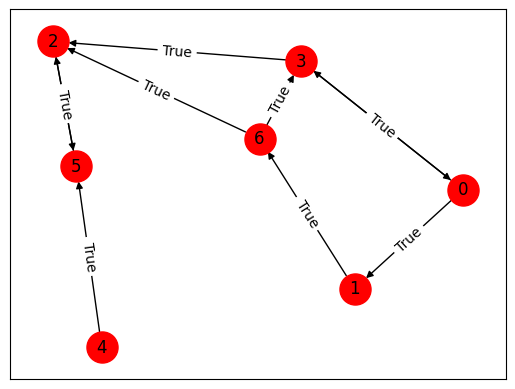

In [ ]:
# Недостижимая вершина 4
edges = [
    [3, 0, 3, 5, 6, 0, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 5, 5, 6],
]
B = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
gb.viz.draw(B.dup(mask=B.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [0,4,6]
MSBFS_Parents(B,s)

[[0, [-1, 0, 3, 0, -2, 2, 1]],
 [4, [-2, -2, 5, -2, -1, 4, -2]],
 [6, [3, 0, 6, 6, -2, 2, -1]]]

##Пример

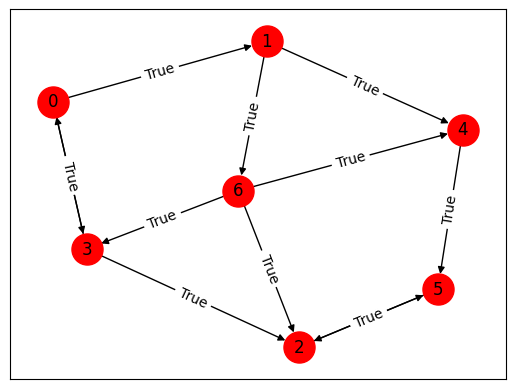

In [ ]:
# пример с практики
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]
C = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
gb.viz.draw(C.dup(mask=C.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [1]
MSBFS_Parents(C,s)

[[1, [3, -1, 6, 6, 1, 4, 1]]]

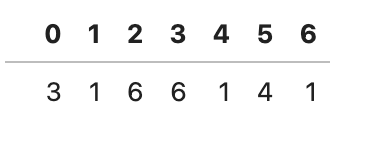

верно

# Задача 3

 (+2 балла) Провести экспериментальное исследование полученных реализаций на некоторых больших графах в формате Matrix Market с сайта SuiteSparse Matrix Collection и на случайных сгенерированных.  
 При этом описать зависимость времени работы всех полученных реализаций от размеров графа, его степени разреженности, количестве стартовых вершин.

In [ ]:
from graphblas.io import mmread
import time
import sys
import random

## Большие графы

In [ ]:
M1 = mmread('/content/crack.mtx')
M1

"M_0"      nvals  nrows  ncols  dtype     format
gb.Matrix  60760  10240  10240   FP64  csr (iso)
------------------------------------------------
      0     1     2     3     4     5     6     7     8     9      ... 10230  \
0                                                                  ...         
1                                                                  ...         
2                                                                  ...         
3                                                                  ...         
4                                                                  ...         
...     ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
10235                                                              ...         
10236                                                              ...         
10237                                                              ...         
10238                                                              ...         
10239                                                              ...         

      10231 10232 10233 10234 10235 10236 10237 10238 10239  
0                                                            
1                                                            
2                                                            
3                                                            
4                                                            
...     ...   ...   ...   ...   ...   ...   ...   ...   ...  
10235   1.0               1.0                                
10236                                       1.0   1.0   1.0  
10237                     1.0         1.0                    
10238                                 1.0                    
10239                                 1.0

In [ ]:
s=[1432]
MSBFS_Levels(M1, s)

[[1432,
  [74,
   76,
   54,
   50,
   55,
   76,
   31,
   41,
   24,
   17,
   36,
   12,
   22,
   41,
   30,
   54,
   65,
   52,
   71,
   42,
   44,
   53,
   61,
   70,
   66,
   58,
   42,
   34,
   18,
   22,
   18,
   9,
   6,
   42,
   36,
   33,
   22,
   33,
   45,
   50,
   53,
   62,
   70,
   60,
   56,
   75,
   73,
   67,
   30,
   32,
   38,
   19,
   14,
   14,
   43,
   42,
   28,
   47,
   53,
   62,
   55,
   68,
   38,
   40,
   44,
   51,
   59,
   22,
   25,
   26,
   67,
   65,
   51,
   49,
   47,
   50,
   48,
   36,
   36,
   26,
   45,
   55,
   62,
   70,
   26,
   47,
   44,
   42,
   30,
   10,
   10,
   4,
   6,
   23,
   44,
   46,
   49,
   56,
   61,
   41,
   37,
   58,
   54,
   50,
   68,
   64,
   62,
   50,
   61,
   69,
   66,
   66,
   45,
   40,
   37,
   38,
   31,
   33,
   41,
   42,
   45,
   49,
   49,
   51,
   51,
   12,
   14,
   23,
   25,
   26,
   27,
   30,
   35,
   23,
   14,
   14,
   10,
   26,
   32,
   36,
   18,
   34,
  

In [ ]:
MSBFS_Parents(M1, s)

[[1432,
  [805,
   764,
   2195,
   1559,
   5645,
   7898,
   5896,
   1612,
   9075,
   1629,
   8934,
   8563,
   9469,
   2101,
   9321,
   2979,
   1968,
   8084,
   2764,
   3467,
   2121,
   2207,
   1964,
   2039,
   3875,
   2633,
   3745,
   2107,
   3041,
   2268,
   2260,
   8806,
   4822,
   2483,
   3425,
   8963,
   3609,
   2310,
   2868,
   2430,
   4593,
   2670,
   2778,
   8029,
   2007,
   8302,
   9249,
   4356,
   4051,
   4905,
   5951,
   10152,
   4867,
   3196,
   10060,
   4207,
   2524,
   1901,
   4794,
   2004,
   4950,
   5085,
   5223,
   6511,
   2872,
   2877,
   6251,
   6917,
   8588,
   2309,
   2759,
   5334,
   8466,
   9361,
   4315,
   3027,
   5285,
   7936,
   4084,
   2314,
   7752,
   2707,
   2676,
   5741,
   3495,
   4767,
   8842,
   2431,
   4726,
   3319,
   4917,
   2411,
   7019,
   4932,
   3255,
   3113,
   2301,
   2887,
   934,
   3729,
   5320,
   3679,
   5353,
   2424,
   5451,
   2621,
   2637,
   7086,
   2025,
   2818,
   

In [ ]:
M2 = mmread('/content/data.mtx')
M2
s=[1]
MSBFS_Levels(M2, s)
MSBFS_Parents(M2, s)

[[1,
  [1,
   -1,
   1,
   1,
   1,
   1,
   0,
   1,
   2,
   2,
   2,
   3,
   8,
   8,
   8,
   9,
   12,
   12,
   12,
   13,
   16,
   16,
   16,
   17,
   20,
   20,
   20,
   21,
   1,
   1,
   1,
   3,
   3,
   7,
   9,
   11,
   13,
   15,
   17,
   19,
   21,
   23,
   28,
   28,
   28,
   29,
   29,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   42,
   42,
   42,
   43,
   43,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   56,
   56,
   56,
   57,
   57,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   70,
   70,
   70,
   71,
   71,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   84,
   84,
   84,
   85,
   85,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   98,
   98,
   98,
   99,
   99,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   112,
   112,
   112,
   113,
   113,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   126,
   126

In [ ]:
M3 = mmread('/content/G5.mtx')
M3
s3=[6]
MSBFS_Levels(M3, s3)
MSBFS_Parents(M3, s3)

[[6,
  [439,
   6,
   22,
   54,
   24,
   537,
   -1,
   224,
   54,
   24,
   43,
   431,
   74,
   134,
   189,
   106,
   224,
   335,
   362,
   235,
   262,
   39,
   6,
   170,
   6,
   111,
   24,
   134,
   1,
   224,
   1,
   262,
   1,
   788,
   1,
   293,
   1,
   189,
   202,
   331,
   24,
   455,
   331,
   6,
   54,
   1,
   170,
   106,
   537,
   235,
   6,
   134,
   1,
   54,
   6,
   74,
   1,
   43,
   202,
   1,
   357,
   54,
   106,
   111,
   168,
   74,
   170,
   54,
   43,
   546,
   262,
   224,
   189,
   20,
   6,
   455,
   54,
   50,
   22,
   672,
   50,
   170,
   54,
   1,
   322,
   43,
   619,
   202,
   235,
   134,
   170,
   202,
   295,
   43,
   134,
   43,
   106,
   24,
   1,
   362,
   54,
   202,
   262,
   189,
   106,
   111,
   6,
   221,
   588,
   588,
   22,
   6,
   293,
   293,
   606,
   455,
   284,
   2,
   221,
   537,
   262,
   598,
   43,
   54,
   293,
   538,
   54,
   183,
   111,
   50,
   170,
   168,
   22,
   322,
 

In [ ]:
def test_BFS(G):
    # Генерация случайных стартовых вершин
    num_vertices = G.nrows #кол-во вершин
    num_edges = len(G.to_coo()[0]) #Кол-во ребер
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1)) if num_vertices > 1 else 0 #разряженность

    num_starting_vertices_list = [1, 5, 10, 100, 250,500]  # Возможные количества стартовых вершин
    data = []  # Список для хранения результатов

    for num_starting_vertices in num_starting_vertices_list:
        s = random.sample(range(G.nrows), num_starting_vertices)  # Выбор случайных вершин

        functions = [MSBFS_Levels, MSBFS_Parents]  # Запоминаем функции для выполнения
        for func in functions:
            start_time = time.time()
            result = func(G, s)  # Передаем граф и список стартовых вершин
            end_time = time.time()

            # Запись данных
            data.append((num_vertices, num_edges, rerefaction_deg ,num_starting_vertices, func.__name__, end_time - start_time))

    # Создание DataFrame для представления данных
    df = pd.DataFrame(data, columns=['Кол-во вершин','Кол-во ребер','Степень разряженности','Кол-воо стартовых вершин', 'Алгоритм', 'Время (сек.)'])

    # Печать данных
    return df

In [ ]:
test_BFS(M1)

,Кол-во вершин,Кол-во ребер,Степень разряженности,Кол-воо стартовых вершин,Алгоритм,Время (сек.)
0,10240,60760,0.00058,1,MSBFS_Levels,0.018265
1,10240,60760,0.00058,1,MSBFS_Parents,0.019058
2,10240,60760,0.00058,5,MSBFS_Levels,0.051482
3,10240,60760,0.00058,5,MSBFS_Parents,0.066349
4,10240,60760,0.00058,10,MSBFS_Levels,0.088790
5,10240,60760,0.00058,10,MSBFS_Parents,0.124601
6,10240,60760,0.00058,100,MSBFS_Levels,0.608420
7,10240,60760,0.00058,100,MSBFS_Parents,2.753870
8,10240,60760,0.00058,250,MSBFS_Levels,1.464037
9,10240,60760,0.00058,250,MSBFS_Parents,2.913154


In [ ]:
test_BFS(M2)

,Кол-во вершин,Кол-во ребер,Степень разряженности,Кол-воо стартовых вершин,Алгоритм,Время (сек.)
0,2851,30186,0.003715,1,MSBFS_Levels,0.010103
1,2851,30186,0.003715,1,MSBFS_Parents,0.007540
2,2851,30186,0.003715,5,MSBFS_Levels,0.018899
3,2851,30186,0.003715,5,MSBFS_Parents,0.026224
4,2851,30186,0.003715,10,MSBFS_Levels,0.026814
5,2851,30186,0.003715,10,MSBFS_Parents,0.037261
6,2851,30186,0.003715,100,MSBFS_Levels,0.195700
7,2851,30186,0.003715,100,MSBFS_Parents,0.345433
8,2851,30186,0.003715,250,MSBFS_Levels,0.436445
9,2851,30186,0.003715,250,MSBFS_Parents,0.752838


In [ ]:
test_BFS(M3)

,Кол-во вершин,Кол-во ребер,Степень разряженности,Кол-воо стартовых вершин,Алгоритм,Время (сек.)
0,800,38352,0.06,1,MSBFS_Levels,0.002186
1,800,38352,0.06,1,MSBFS_Parents,0.002335
2,800,38352,0.06,5,MSBFS_Levels,0.009583
3,800,38352,0.06,5,MSBFS_Parents,0.009927
4,800,38352,0.06,10,MSBFS_Levels,0.004225
5,800,38352,0.06,10,MSBFS_Parents,0.018044
6,800,38352,0.06,100,MSBFS_Levels,0.028403
7,800,38352,0.06,100,MSBFS_Parents,0.084694
8,800,38352,0.06,250,MSBFS_Levels,0.060133
9,800,38352,0.06,250,MSBFS_Parents,0.201002


### Выводы

* При увеличении `кол-ва стартовых вершин` время выполнения обоих алгоритмов  возрастает. Увеличение числа стартовых вершин напрямую влияет на размерность строк фронта, что усложняет операцию матричного умножения.
* При увелечении `размеров графа` (кол-во вершин, кол-во ребер) время выполнения обоих алгоритмов  возрастает. Это связано с увеличением количества столбцов в матрицах, что усложняет операцию матричного умножения
* В сравнении друг с другом, алгоритм `msbfs_parents` начинает работать медленнее, чем `msbfs_levels`, по мере увеличения размеров графа.

## случайные графы

In [ ]:
# Функции для теста
def gen_vertices(num_vertices, vertex_frac):
    #генерация стартовых вершин в зависимости от числа вершин (num_vertices) и доли (в %) стартовых вершин от общего числа (vertex_frac)
    start_vertices = random.sample(range(num_vertices), int(vertex_frac / 100 * num_vertices))
    return np.array(start_vertices)
def test_Levels(A, start_vertices):
    print('msbfs_levels:')
    %timeit MSBFS_Levels(A, start_vertices)
    print()

def test_Parents(A, start_vertices):
    print('msbfs_parents:')
    %timeit MSBFS_Parents(A, start_vertices)
    print()

In [ ]:
# Тестирование на случайно сгенерированных графах

def generate_graph(num_vertices, num_edges):
    # Создание множества (без диагональных элементов)
    positions = []
    for ind in range(num_vertices**2):
        if ind // num_vertices != ind % num_vertices:
            positions.append(ind)
    # Отбор num_edges случайных индексов вершин (случайные значения из high_positions) для создания ребер
    gen_indices = random.sample(positions, num_edges)
    # Преобразуем в координаты (строка, столбец)
    row_indices, col_indices = np.unravel_index(gen_indices, (num_vertices, num_vertices))

    return Matrix.from_coo(row_indices, col_indices, [1]*len(row_indices), nrows=num_vertices, ncols=num_vertices)

### Число вершин

Фиксирую:
* степень разряженности = 0,7.
* Доля стартовых вершин = 60%.
  
Меняю - число вершин

In [ ]:
# Зависимость от числа вершин (при фиксированной степени разреженности и фиксированном числе стартовых вершин)
for i in [100, 200, 400, 800]:
    fix_raref_deg, num_starts = 0.7, 60  # Фиксированные значения степени разреженности и числа стартовых вершин
    generated_graph = generate_graph(i, int(fix_raref_deg * i * (i-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Levels(generated_graph, gen_vertices(i, num_starts))
    test_Parents(generated_graph, gen_vertices(i, num_starts))

Количество вершин: 100, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
14 ms ± 6.42 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

msbfs_parents:
19.6 ms ± 4.18 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

Количество вершин: 200, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
27 ms ± 4.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
98.3 ms ± 33.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 400, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
96.9 ms ± 18.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
349 ms ± 115 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 800, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
409 ms ± 98.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

msbfs_parents:
1.96 s ± 809 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)



### Степень разряженности

Фиксирую:
* Число вершин  = 600
* Число стартовых вершин  = 50

Меняю степень разреженности

In [ ]:
for i in [0.2, 0.4, 0.6, 0.8]:
    num_vert, num_starts = 600, 50
    generated_graph = generate_graph(num_vert, int(i * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Levels(generated_graph, gen_vertices(num_vert, num_starts))
    test_Parents(generated_graph, gen_vertices(num_vert, num_starts))

Количество вершин: 600, степень разреженности: 0.20, доля стартовых вершин: 50%
msbfs_levels:
66.8 ms ± 1.61 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
326 ms ± 49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.40, доля стартовых вершин: 50%
msbfs_levels:
197 ms ± 23.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

msbfs_parents:
531 ms ± 181 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.60, доля стартовых вершин: 50%
msbfs_levels:
168 ms ± 38.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
867 ms ± 234 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.80, доля стартовых вершин: 50%
msbfs_levels:
127 ms ± 32.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
430 ms ± 8.98 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)



### Доля стартовых вершин

Фиксирую:
* Число вершин  = 600
* степень разряженности = 0,7.

Меняю стратовых вершин  

In [ ]:
for i in [20, 40, 60, 80]:
    num_vert, fix_raref_deg = 600, 0.7  # Фиксированные число вершин и значение степени разреженности
    generated_graph = generate_graph(num_vert, int(fix_raref_deg * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {i}%')
    test_Levels(generated_graph, gen_vertices(num_vert, i))
    test_Parents(generated_graph, gen_vertices(num_vert, i))

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 20%
msbfs_levels:
55.8 ms ± 13.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
275 ms ± 65.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 40%
msbfs_levels:
93 ms ± 1.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
681 ms ± 315 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
159 ms ± 30 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
659 ms ± 12.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 80%
msbfs_levels:
264 ms ± 118 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
877 ms ± 12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)



msbfs_levels:
61 ms ± 16.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
218 ms ± 5.33 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 20%
msbfs_levels:
108 ms ± 28.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
447 ms ± 13.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 40%
msbfs_levels:
231 ms ± 53.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
1.07 s ± 355 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
208 ms ± 42.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

msbfs_parents:
874 ms ± 7.72 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 80%


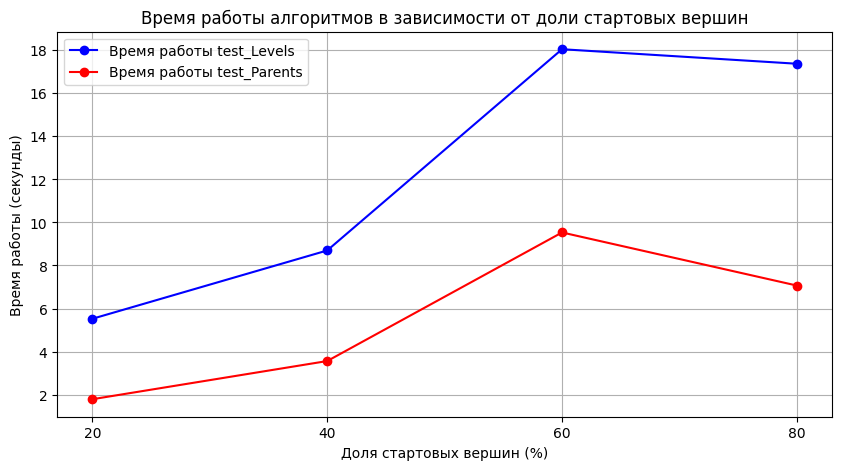

In [ ]:
import matplotlib.pyplot as plt
import time


time_levels = []
time_parents = []
x_values = [20, 40, 60, 80]

for i in x_values:
    num_vert, fix_raref_deg = 600, 0.7
    generated_graph = generate_graph(num_vert, int(fix_raref_deg * num_vert * (num_vert - 1)))
    start_time = time.time()
    test_Levels(generated_graph, gen_vertices(num_vert, i))
    elapsed_time_levels = time.time() - start_time
    time_levels.append(elapsed_time_levels)

    start_time = time.time()
    test_Parents(generated_graph, gen_vertices(num_vert, i))
    elapsed_time_parents = time.time() - start_time
    time_parents.append(elapsed_time_parents)

    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {i}%')


plt.figure(figsize=(10, 5))
plt.plot(x_values, time_levels, marker='o', label='Время работы test_Levels', color='blue')
plt.plot(x_values, time_parents, marker='o', label='Время работы test_Parents', color='red')
plt.title('Время работы алгоритмов в зависимости от доли стартовых вершин')
plt.xlabel('Доля стартовых вершин (%)')
plt.ylabel('Время работы (секунды)')
plt.xticks(x_values)
plt.legend()
plt.grid()
plt.show()


##Выводы

* С увеличением `числа вершин` наблюдается рост времени выполнения обоих алгоритмов. Это обусловлено увеличением количества столбцов в матрицах, что усложняет процесс матричного умножения. Алгоритм msbfs_levels показывает приблизительно линейную зависимость времени от числа вершин, тогда как второй алгоритм демонстрирует более выраженное увеличение времени, что свидетельствует о степенной зависимости.

* С увеличением числа `стартовых вершин ` также наблюдается рост времени выполнения алгоритмов. Это связано с тем, что увеличение стартовых вершин непосредственно влияет на размер строк фронта, что усложняет процесс матричного умножения.

* С увеличением `степени разреженности ` графа явной зависимости времени выполнения не наблюдается. Более того, проведенные тесты продемонстрировали, что алгоритмы работают быстрее на графах со средней степенью разреженности. Это можно объяснить тем, что алгоритмы оптимизированы под реальные графы, которые, как правило, не являются почти полными или чрезмерно разреженными.

# Задача 4

* (+3 балла) Добавить реализации описанных алгоритмов с использованием других полуколец (any.pair для levels и any.first для parents).  
* Добавить тесты для проверки корректности. Провести экспериментальное исследование со сравнением этих реализаций с первоначальными на различных графах.

## any.pair для levels

In [ ]:
def MSBFS_Levels_AnyPair(M, s):
  n = M.nrows #определеям кол-во вершин
  result_1 = Matrix(dtypes.INT32, len(s), n) #создаем матрицу для хранения результатов
  f_1 = Matrix(bool, len(s), n) #создаем фронт вершин
  for i in range(len(s)):
    f_1[i, s[i]] << True #присваиваем начальным вершинам тру
  level = 0
  for level in range(n-1):
    result_1(mask=f_1.V) << level #Записываем результат во фронт
    level += 1
    f_1_before = f_1.dup() #Создаем копию фронта для сравнения
    #перезаписываем результат, используем комплименатрую маску вектора результата (берем струткуру .S)
    f_1(~result_1.S, replace=True) << f_1.mxm(M, semiring.any_pair) # Матричное умножение в полукольце булевом для вычисления следующего фронта вершин
    # Проверка, достигнута ли хоть одна вершина в следующем фронтири ???
    if f_1.isequal(f_1_before):  # Если фронт не изменился, то прерываем цикл
      break
  pairs = []

  for i in range(result_1.shape[0]):
      result_app = result_1[i, :]  # Получаем i-ю строку
    # Добавляем к парам (индекс, строка)
      pairs.append([s[i], result_app.to_dense(fill_value=-1).tolist()])
  return pairs

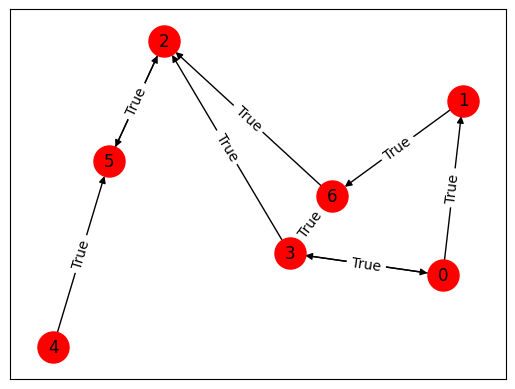

In [ ]:
# Недостижимая вершина 4
edges = [
    [3, 0, 3, 5, 6, 0, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 5, 5, 6],
]
B = Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])
gb.viz.draw(B.dup(mask=B.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [0,1,2]
MSBFS_Levels(B,s)

[[0, [0, 1, 2, 1, -1, 3, 2]],
 [1, [3, 0, 2, 2, -1, 3, 1]],
 [2, [-1, -1, 0, -1, -1, 1, -1]]]

In [ ]:
s=[0,1,2]
MSBFS_Levels_AnyPair(B,s)

[[0, [0, 1, 2, 1, -1, 3, 2]],
 [1, [3, 0, 2, 2, -1, 3, 1]],
 [2, [-1, -1, 0, -1, -1, 1, -1]]]

### Сравнение результатов

In [ ]:
s = [0,4]
MSBFS_Levels(C,s)

[[0, [0, 1, 2, 1, 2, 3, 2]], [4, [-1, -1, 2, -1, 0, 1, -1]]]

In [ ]:
s = [0,4]
MSBFS_Levels_AnyPair(C,s)

[[0, [0, 1, 2, 1, 2, 3, 2]], [4, [-1, -1, 2, -1, 0, 1, -1]]]

In [ ]:
import random
import time
import pandas as pd

def test_BFS_MSBFS_Levels(G):
    num_starting_vertices_list = [1, 5,100, 250,1500, 5000]
    data = []

    for num_starting_vertices in num_starting_vertices_list:
        s = random.sample(range(G.nrows), num_starting_vertices)
        functions = [MSBFS_Levels, MSBFS_Levels_AnyPair]
        results = []

        for func in functions:
            start_time = time.time()
            result = func(G, s)
            end_time = time.time()

            results.append(result)
            data.append((G.nrows, num_starting_vertices, func.__name__, end_time - start_time))
        if results[0] == results[1]:
            match = 1
        else:
            match = 0
        data[-2] = data[-2] + (match,)
        data[-1] = data[-1] + (match,)
    df = pd.DataFrame(data, columns=['Размер графа', 'Кол-во стартовых вершин', 'Алгоритм', 'Время (сек.)', 'Совпадение'])
    return df


In [ ]:
test_BFS_MSBFS_Levels(M1)

,Размер графа,Кол-во стартовых вершин,Алгоритм,Время (сек.),Совпадение
0,10240,1,MSBFS_Levels,0.032809,1
1,10240,1,MSBFS_Levels_AnyPair,0.016888,1
2,10240,5,MSBFS_Levels,0.046795,1
3,10240,5,MSBFS_Levels_AnyPair,0.045108,1
4,10240,100,MSBFS_Levels,0.562719,1
5,10240,100,MSBFS_Levels_AnyPair,0.585528,1
6,10240,250,MSBFS_Levels,1.330737,1
7,10240,250,MSBFS_Levels_AnyPair,1.395769,1
8,10240,1500,MSBFS_Levels,9.231863,1
9,10240,1500,MSBFS_Levels_AnyPair,7.476093,1


In [ ]:
test_BFS_MSBFS_Levels(M2)

,Размер графа,Кол-во стартовых вершин,Алгоритм,Время (сек.),Совпадение
0,2851,1,MSBFS_Levels,0.011180,1
1,2851,1,MSBFS_Levels_AnyPair,0.008181,1
2,2851,5,MSBFS_Levels,0.020383,1
3,2851,5,MSBFS_Levels_AnyPair,0.019906,1
4,2851,10,MSBFS_Levels,0.027323,1
5,2851,10,MSBFS_Levels_AnyPair,0.028441,1
6,2851,100,MSBFS_Levels,0.316033,1
7,2851,100,MSBFS_Levels_AnyPair,0.548986,1
8,2851,250,MSBFS_Levels,1.216029,1
9,2851,250,MSBFS_Levels_AnyPair,0.623888,1


In [ ]:
test_BFS_MSBFS_Levels(M3)

,Размер графа,Кол-во стартовых вершин,Алгоритм,Время (сек.),Совпадение
0,800,1,MSBFS_Levels,0.002991,1
1,800,1,MSBFS_Levels_AnyPair,0.001626,1
2,800,5,MSBFS_Levels,0.002549,1
3,800,5,MSBFS_Levels_AnyPair,0.002387,1
4,800,10,MSBFS_Levels,0.004402,1
5,800,10,MSBFS_Levels_AnyPair,0.003822,1
6,800,100,MSBFS_Levels,0.029237,1
7,800,100,MSBFS_Levels_AnyPair,0.029034,1
8,800,250,MSBFS_Levels,0.067215,1
9,800,250,MSBFS_Levels_AnyPair,0.062845,1


In [ ]:
# Функции для теста
def gen_vertices(num_vertices, vertex_frac):
    #генерация стартовых вершин в зависимости от числа вершин (num_vertices) и доли (в %) стартовых вершин от общего числа (vertex_frac)
    start_vertices = random.sample(range(num_vertices), int(vertex_frac / 100 * num_vertices))
    return np.array(start_vertices)
def test_Levels(A, start_vertices):
    print('msbfs_levels:')
    %timeit MSBFS_Levels(A, start_vertices)
    print()

def test_Levels_anypair(A, start_vertices):
    print('MSBFS_Levels_AnyPair:')
    %timeit MSBFS_Levels_AnyPair(A, start_vertices)
    print()


In [ ]:
# Зависимость от числа вершин (при фиксированной степени разреженности и фиксированном числе стартовых вершин)
for i in [100, 200, 2500]:
    fix_raref_deg, num_starts = 0.7, 60  # Фиксированные значения степени разреженности и числа стартовых вершин
    generated_graph = generate_graph(i, int(fix_raref_deg * i * (i-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Levels(generated_graph, gen_vertices(i, num_starts))
    test_Levels_anypair(generated_graph, gen_vertices(i, num_starts))

Количество вершин: 100, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
10.8 ms ± 2.75 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

MSBFS_Levels_AnyPair:
10.8 ms ± 3.12 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

Количество вершин: 200, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
21.3 ms ± 3.37 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

MSBFS_Levels_AnyPair:
23 ms ± 4.07 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

Количество вершин: 2500, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
6.92 s ± 372 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Levels_AnyPair:
7.47 s ± 963 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)



In [ ]:
#Степень разряженности
for i in [0.2, 0.4, 0.6, 0.8]:
    num_vert, num_starts = 600, 50
    generated_graph = generate_graph(num_vert, int(i * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Levels(generated_graph, gen_vertices(num_vert, num_starts))
    test_Levels_anypair(generated_graph, gen_vertices(num_vert, num_starts))

Количество вершин: 600, степень разреженности: 0.20, доля стартовых вершин: 50%
msbfs_levels:
The slowest run took 4.38 times longer than the fastest. This could mean that an intermediate result is being cached.
166 ms ± 97.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
76.3 ms ± 20.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.40, доля стартовых вершин: 50%
msbfs_levels:
151 ms ± 46.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Levels_AnyPair:
96.2 ms ± 1.52 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.60, доля стартовых вершин: 50%
msbfs_levels:
142 ms ± 31.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
150 ms ± 31.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.80, доля стартовых вершин: 50%
msbfs_levels:
139 ms ± 41.7 

In [ ]:
#Доля стартовых вершин
for i in [20, 40, 60, 80]:
    num_vert, fix_raref_deg = 600, 0.7  # Фиксированные число вершин и значение степени разреженности
    generated_graph = generate_graph(num_vert, int(fix_raref_deg * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {i}%')
    test_Levels(generated_graph, gen_vertices(num_vert, i))
    test_Levels_anypair(generated_graph, gen_vertices(num_vert, i))

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 20%
msbfs_levels:
51 ms ± 2.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
70.1 ms ± 15.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 40%
msbfs_levels:
106 ms ± 18.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
122 ms ± 24.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 60%
msbfs_levels:
161 ms ± 35.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
156 ms ± 30.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 80%
msbfs_levels:
199 ms ± 36.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Levels_AnyPair:
198 ms ± 31 ms per loop (mean ± std. de

### Вывод

При небольших размерах графа, малой доле стартовых начальных вершин, и повышенной или заниженной степени разряженности алгротим на `lor_land `
справляется с задачей быстрее

 Но при увеличения плотности графа, его размера и числа стартовых вершин применение полукольца `any_pair` способствует сокращению времени выполнения.

## any.first для parents


In [ ]:
def MSBFS_Parents_AnyFirst(A, s):
    N = A.nrows  #определеям кол-во вершин
    index_ramp = Matrix(dtypes.UINT64, len(s), N)
    parents = Matrix(dtypes.UINT64, len(s), N)
    row_indices = []
    col_indices = []
    values = []
    for i in range(len(s)):
        for j in range(N):
            row_indices.append(i)
            col_indices.append(j)
            values.append(j)
    index_ramp.build(row_indices, col_indices, values)
    for i in range(len(s)):
        parents[i, s[i]] << N + 1  #Уставновка значения стартовых вершин, чтобы потом поменяться на -1
    wavefront = Matrix(dtypes.UINT64, len(s), N)
    for i in range(len(s)):
        wavefront[i, s[i]] << 0

    while wavefront.nvals > 0:  # Проверка на ненулевые значения
        wavefront << index_ramp.ewise_mult(wavefront, binary.first)
        wavefront(~parents.S, replace=True) << wavefront.mxm(A, semiring.any_first)
        parents(binary.plus) << wavefront
    pairs = []
    for i in range(parents.shape[0]):
        parents_app = parents[i, :]
        pairs.append([s[i], [(-1 if val > N else int(val)) for val in parents_app.to_dense(fill_value=-2).tolist()]])

    return pairs


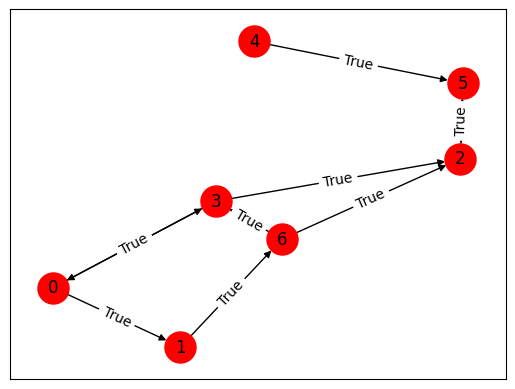

In [ ]:
gb.viz.draw(B.dup(mask=B.dup(dtype=dtypes.BOOL)))

In [ ]:
s = [0,4]
MSBFS_Parents(B,s)

[[0, [-1, 0, 3, 0, -2, 2, 1]], [4, [-2, -2, 5, -2, -1, 4, -2]]]

In [ ]:
s = [0,4]
MSBFS_Parents_AnyFirst(B,s)

[[0, [-1, 0, 3, 0, -2, 2, 1]], [4, [-2, -2, 5, -2, -1, 4, -2]]]

In [ ]:
# Функции для теста
def gen_vertices(num_vertices, vertex_frac):
    #генерация стартовых вершин в зависимости от числа вершин (num_vertices) и доли (в %) стартовых вершин от общего числа (vertex_frac)
    start_vertices = random.sample(range(num_vertices), int(vertex_frac / 100 * num_vertices))
    return np.array(start_vertices)
def test_Parents_MinFirst(A, start_vertices):
    print('MSBFS_Parents_MinFirst:')
    %timeit MSBFS_Parents(A, start_vertices)
    print()

def test_Parents_AnyFirst(A, start_vertices):
    print('MSBFS_Parents_AnyFirst:')
    %timeit MSBFS_Parents_AnyFirst(A, start_vertices)
    print()


In [ ]:
# Зависимость от числа вершин (при фиксированной степени разреженности и фиксированном числе стартовых вершин)
for i in [100, 200, 500,1000]:
    fix_raref_deg, num_starts = 0.7, 60  # Фиксированные значения степени разреженности и числа стартовых вершин
    generated_graph = generate_graph(i, int(fix_raref_deg * i * (i-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Parents_MinFirst(generated_graph, gen_vertices(i, num_starts))
    test_Parents_AnyFirst(generated_graph, gen_vertices(i, num_starts))

Количество вершин: 100, степень разреженности: 0.70, доля стартовых вершин: 60%
MSBFS_Parents_MinFirst:
17 ms ± 2.44 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

MSBFS_Parents_AnyFirst:
16.4 ms ± 3.57 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

Количество вершин: 200, степень разреженности: 0.70, доля стартовых вершин: 60%
MSBFS_Parents_MinFirst:
53.4 ms ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Parents_AnyFirst:
51 ms ± 13.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 500, степень разреженности: 0.70, доля стартовых вершин: 60%
MSBFS_Parents_MinFirst:
413 ms ± 11.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
379 ms ± 12.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 1000, степень разреженности: 0.70, доля стартовых вершин: 60%
MSBFS_Parents_MinFirst:
2.91 s ± 351 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFi

In [ ]:
#Степень разряженности
for i in [0.2, 0.4, 0.6, 0.8]:
    num_vert, num_starts = 600, 50
    generated_graph = generate_graph(num_vert, int(i * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {num_starts}%')
    test_Parents_MinFirst(generated_graph, gen_vertices(num_vert, num_starts))
    test_Parents_AnyFirst(generated_graph, gen_vertices(num_vert, num_starts))

Количество вершин: 600, степень разреженности: 0.20, доля стартовых вершин: 50%
MSBFS_Parents_MinFirst:
191 ms ± 42.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

MSBFS_Parents_AnyFirst:
178 ms ± 45.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Количество вершин: 600, степень разреженности: 0.40, доля стартовых вершин: 50%
MSBFS_Parents_MinFirst:
327 ms ± 8.44 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
302 ms ± 11.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.60, доля стартовых вершин: 50%
MSBFS_Parents_MinFirst:
792 ms ± 224 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
620 ms ± 12.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.80, доля стартовых вершин: 50%
MSBFS_Parents_MinFirst:
447 ms ± 6.75 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
59

In [ ]:
#Доля стартовых вершин
for i in [20, 40, 60, 80]:
    num_vert, fix_raref_deg = 600, 0.7  # Фиксированные число вершин и значение степени разреженности
    generated_graph = generate_graph(num_vert, int(fix_raref_deg * num_vert * (num_vert-1)))
    num_vertices = generated_graph.shape[0]
    num_edges = len(generated_graph.to_coo()[0])
    rerefaction_deg = num_edges / (num_vertices * (num_vertices - 1))
    print(f'Количество вершин: {num_vertices}, степень разреженности: {rerefaction_deg:.2f}, доля стартовых вершин: {i}%')
    test_Parents_MinFirst(generated_graph, gen_vertices(num_vert, i))
    test_Parents_AnyFirst(generated_graph, gen_vertices(num_vert, i))

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 20%
MSBFS_Parents_MinFirst:
223 ms ± 6.03 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
312 ms ± 67.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 40%
MSBFS_Parents_MinFirst:
457 ms ± 11.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
425 ms ± 10.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 60%
MSBFS_Parents_MinFirst:
854 ms ± 226 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
622 ms ± 5.82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Количество вершин: 600, степень разреженности: 0.70, доля стартовых вершин: 80%
MSBFS_Parents_MinFirst:
1.07 s ± 288 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

MSBFS_Parents_AnyFirst:
832 ms 

### Вывод

По мере того как характеристики графов становятся ближе к реальным задачам, алгоритм, основанный на полукольце `any_first`, демонстрирует аналогичную производительность с исходным полукольцом (`min_first`) при небольших значениях.   
Это объясняется тем, что выбор первого элемента и поиск минимального элемента могут быть эффективными подходами в различных сценариях.  
Когда требуется выбрать первый подходящий элемент, такая стратегия оказывается более результативной при большом количестве подходящих вариантов.  

при увеличении количества стартовых вершин, исходное полукольцо показывает значительно лучшую производительность, что, вероятно, связано с оптимизированной схемой выбора минимального элемента.